In [1]:
import networkx as nx
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from utils import load_graph, load_pickle_file, save_pickle_file
import math
import os

dir = "datasets"
files = [f for f in os.listdir(dir)]

n_files = len(files)
n_cols = 2
n_rows = math.ceil(n_files / n_cols)

## Topology

Considering the surprising variation in results between the wikipedia data and the facebook data, here we are going to analyse the topology of the two graphs based on three metrics:
* Degree centrality
* Betweenness centrality
* Clustering
In order to discern a possible cause.

### Degree distribution (and SF networks)

The degree $k$ of a node in an undirected graph is the number of edges that are incidental to it, i.e. the number of "neighbors" that is has.

The degree distribution $P(k)$ is the probability distribution of the degrees of the nodes over the whole network.

A scale-free network is a network whose degree distribution follows a power law, at least asymptotically. That is, there is an inverse exponential relation between the number of nodes and degree. On a log-log chart, this manifests as close to a diagonal line.

In plainer language, this means that they typically have a small minority of nodes with $k$ greatly above the average. This increases degree heterogeneity: $\frac{\langle k² \rangle}{\langle k \rangle}$ and places exponentially more importance on hubs as spreaders and blockers in an information cascade.

Some social networks have been shown to be scale-free. Below, we plot the degree distribution of two social networks:

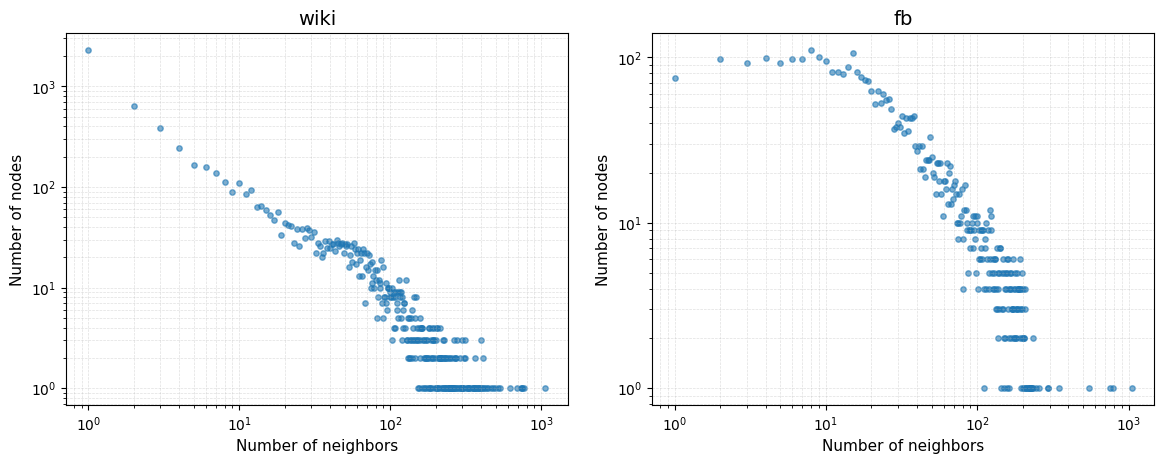

In [26]:
def get_degrees(G):
    degrees = [d for _, d in G.degree()]
    return Counter(degrees)

fig, axes = plt.subplots(n_rows,n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for ax, filename in zip(axes, files):
    path = os.path.join(dir, filename)

    G = load_graph(path)
    degree_counts = get_degrees(G)

    ax.scatter(degree_counts.keys(), degree_counts.values(), s=15, alpha=0.6)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_xlabel("Number of neighbors", fontsize=11)
    ax.set_ylabel("Number of nodes", fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(os.path.splitext(filename)[0], fontsize=14)

    """ if filename.__contains__("wiki"):
        x1 = 1
        y1 = degree_counts[1]

        ax.annotate(
            "The majority of nodes\nhave only one neighbor",
            xy=(x1, y1),
            xytext=(120,-60),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="->",
                color="orange",
                connectionstyle="arc3,rad=0.25",
                linewidth=1
            ),
            bbox=dict(
                boxstyle="round,pad=0.6",
                fc="white",
                ec="orange",
                alpha=0.8
            ),
            fontsize=10
        ) """

plt.tight_layout(pad=2.0)
plt.show()

### Betweenness Centrality

The betweenness of a node quantifies how often a node is included in the shortest path between two other nodes.

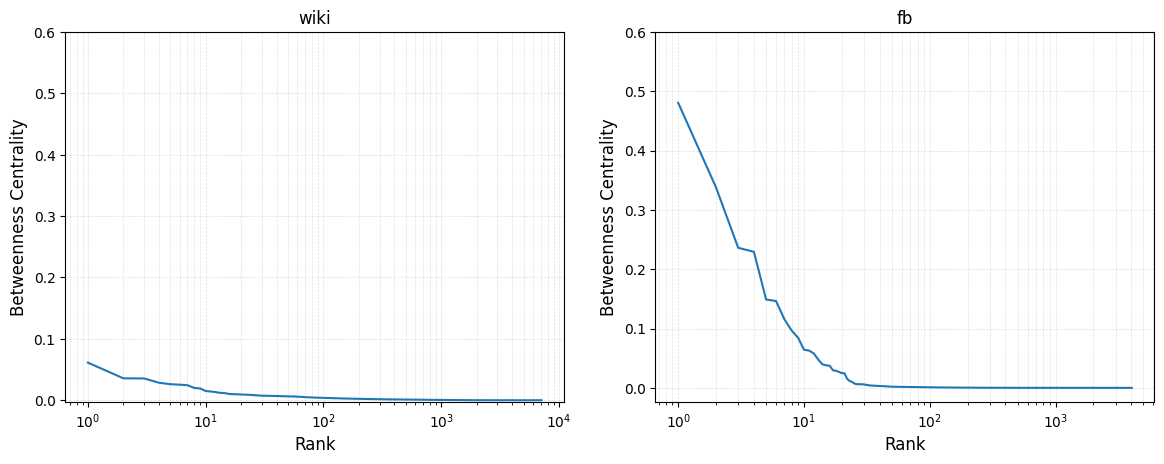

In [2]:
base_dir = "centrality"

fig, axes = plt.subplots(n_rows,n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for ax, filename in zip(axes, files):
    graph_path = os.path.join(dir, filename)
    centrality_path = os.path.join(base_dir, filename[:-4] + "_betweenness.pkl")

    G = load_graph(graph_path)
    centrality = load_pickle_file(centrality_path) 

    """ values = list(centrality.values())
    hist, bin_edges = np.histogram(values, bins=50)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # plt.plot(bin_centers, hist, label=filename[:-4])
    ax.scatter(bin_centers, hist, s=15, alpha=0.7, label=filename[:-4]) """

    """ centrality_values = list(centrality.values())
    ax.hist(centrality_values, bins = 50) """

    centrality_values = sorted(centrality.values(), reverse=True)
    ranks = range(1, len(centrality_values) + 1)

    ax.plot(ranks, centrality_values)

    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlabel("Rank", fontsize=12)
    ax.set_ylabel("Betweenness Centrality", fontsize=12)
    ax.set_ylim(top=0.6)
    ax.set_title(filename[:-4])

plt.tight_layout(pad=2.0)
plt.show()

### Clustering

For a node i, its clustering coeffcient $c_{i}$ indicates the number of existing links between its neighbors out of all possible links. For a node with $k = 2$, $c_i = 1$ if its neighbors are connected, $0$ if not.

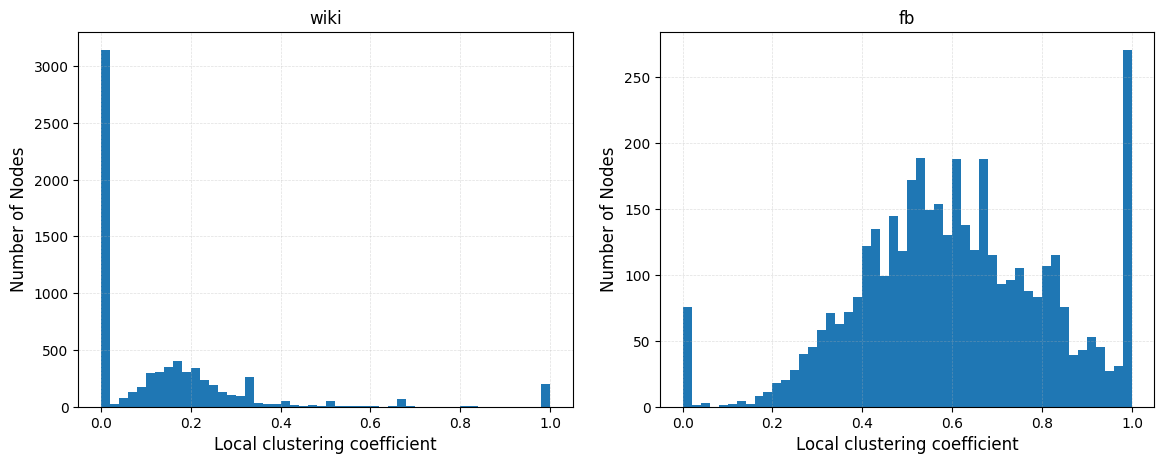

In [ ]:
fig, axes = plt.subplots(n_rows,n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for ax, filename in zip(axes, files):
    path = os.path.join(dir, filename)

    G = load_graph(path)
    clustering = nx.clustering(G)

    clustering_values = list(clustering.values())
    ax.hist(clustering_values, bins=50)

    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_xlabel("Local clustering coefficient", fontsize=12)
    ax.set_ylabel("Number of Nodes", fontsize=12)
    ax.set_title(filename[:-4])

plt.tight_layout(pad=2.0)
plt.show()

### Clustering vs degree

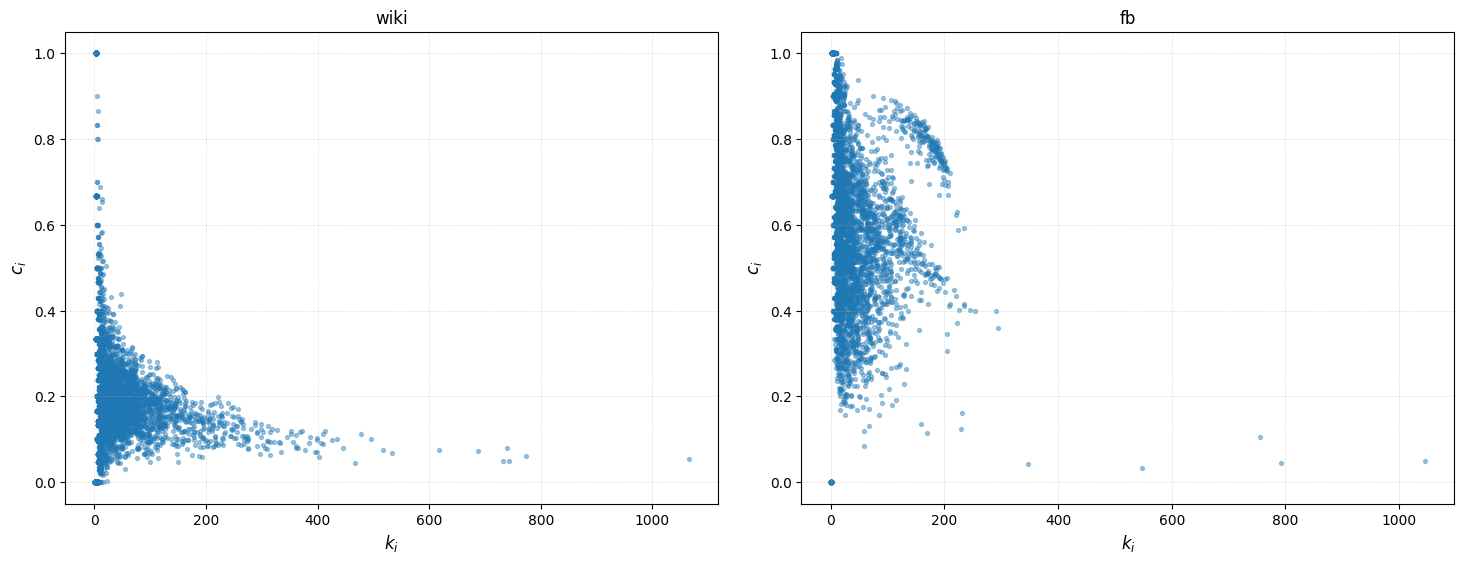

In [40]:
fig, axes = plt.subplots(n_rows,n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten()

for ax, filename in zip(axes, files):
    path = os.path.join(dir, filename)

    G = load_graph(path)
    clustering = nx.clustering(G)
    degrees = dict(G.degree())

    clustering_values = list(clustering.values())

    ax.scatter(list(degrees.values()), clustering_values, s=8, alpha=0.4,)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_xlabel(r"$k_i$", fontsize=12)
    ax.set_ylabel(r"$c_i$", fontsize=12)
    ax.set_title(filename[:-4])

plt.tight_layout(pad=2.0)
plt.show()

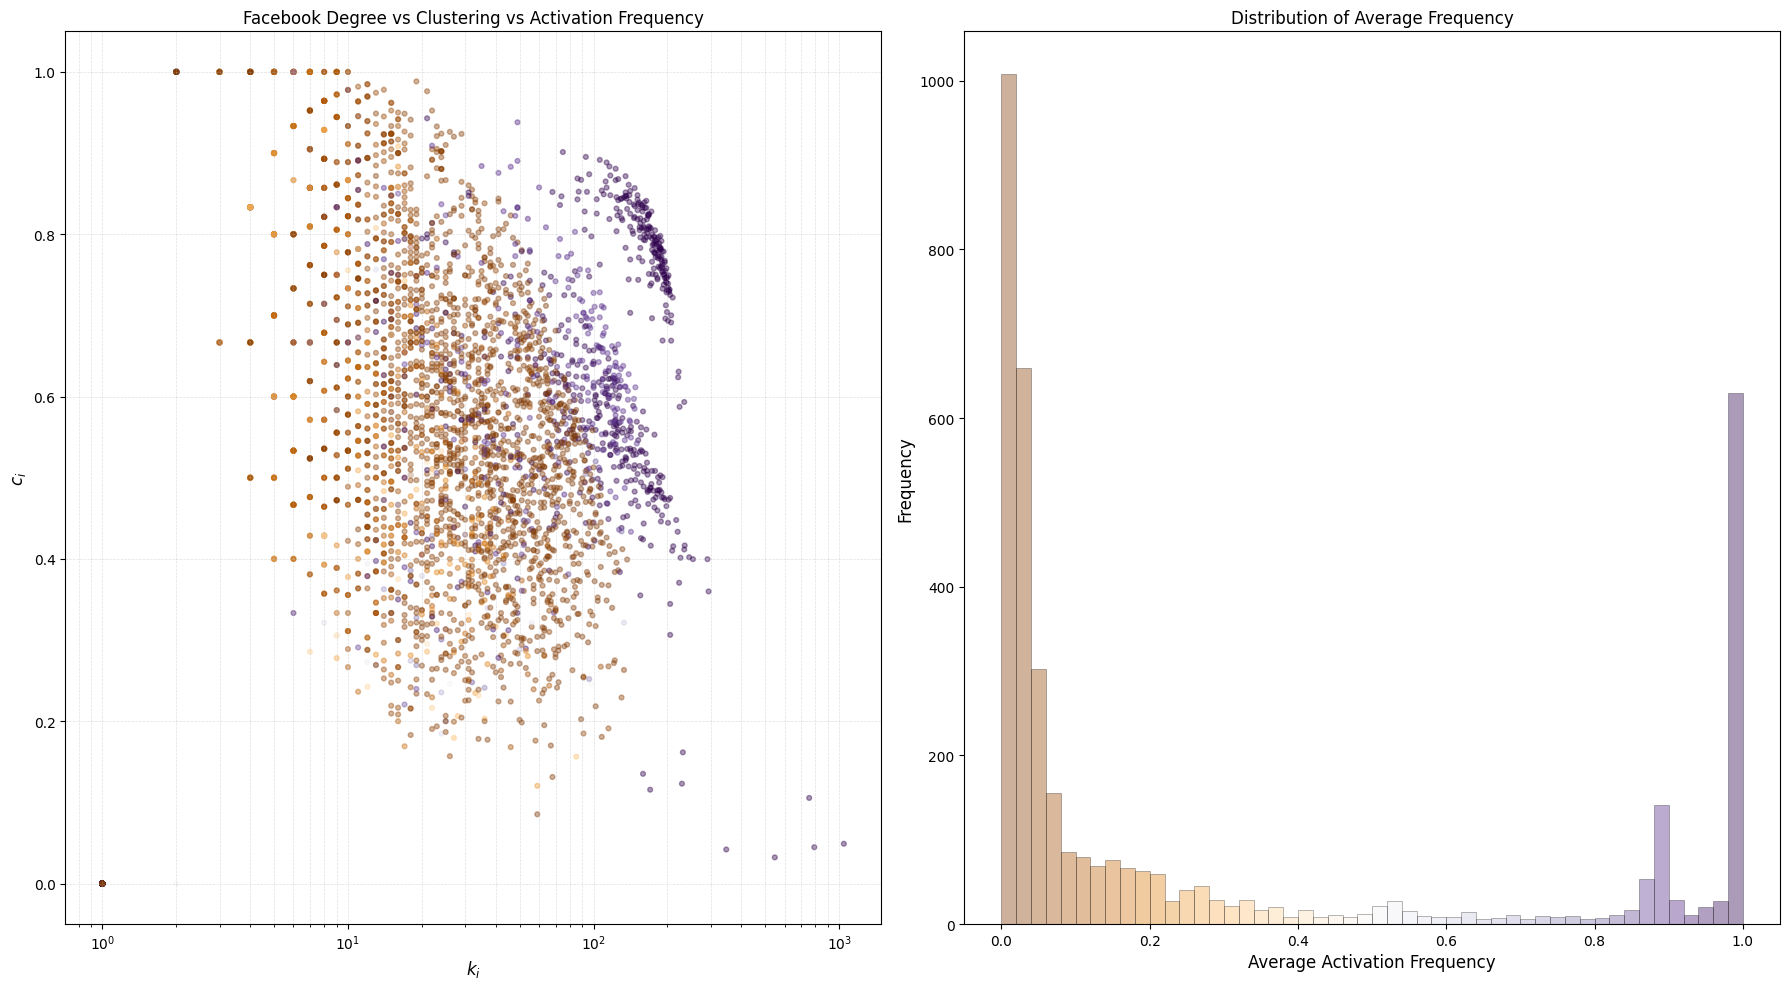

In [54]:
G = load_graph("datasets/fb.txt")

# Prepare clustering, degree and activation frequency
clustering = nx.clustering(G)
clustering_values = list(clustering.values())

degrees = dict(G.degree())

averages = load_pickle_file("avg_results/fb/threshold_norm/fIA_0.050/mean_0.5_std_0.25/HD_averages.pkl")
avg_frequency = averages["avg_frequency"]  # List with length = len(G)

# Prepare fig and color mapping
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

norm = plt.Normalize(vmin=min(avg_frequency), vmax=max(avg_frequency))
cmap = cm.PuOr

scatter = ax1.scatter(list(degrees.values()), clustering_values, c=avg_frequency, cmap=cmap, s=12, alpha=0.4)

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)

# Add color bar
""" cbar = plt.colorbar(scatter)
cbar.set_label("Average Frequency", fontsize=12) """

# Labels and title
ax1.set_xlabel(r"$k_i$", fontsize=12)
ax1.set_xscale("log")
ax1.set_ylabel(r"$c_i$", fontsize=12)
ax1.set_title("Facebook Degree vs Clustering vs Activation Frequency")

n, bins, patches = ax2.hist(avg_frequency, edgecolor="black", linewidth=0.5, bins=50, alpha=0.4)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
colors = cm.PuOr(norm(bin_centers))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax2.set_title("Distribution of Average Frequency")
ax2.set_xlabel("Average Activation Frequency", fontsize=12)
ax2.set_ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

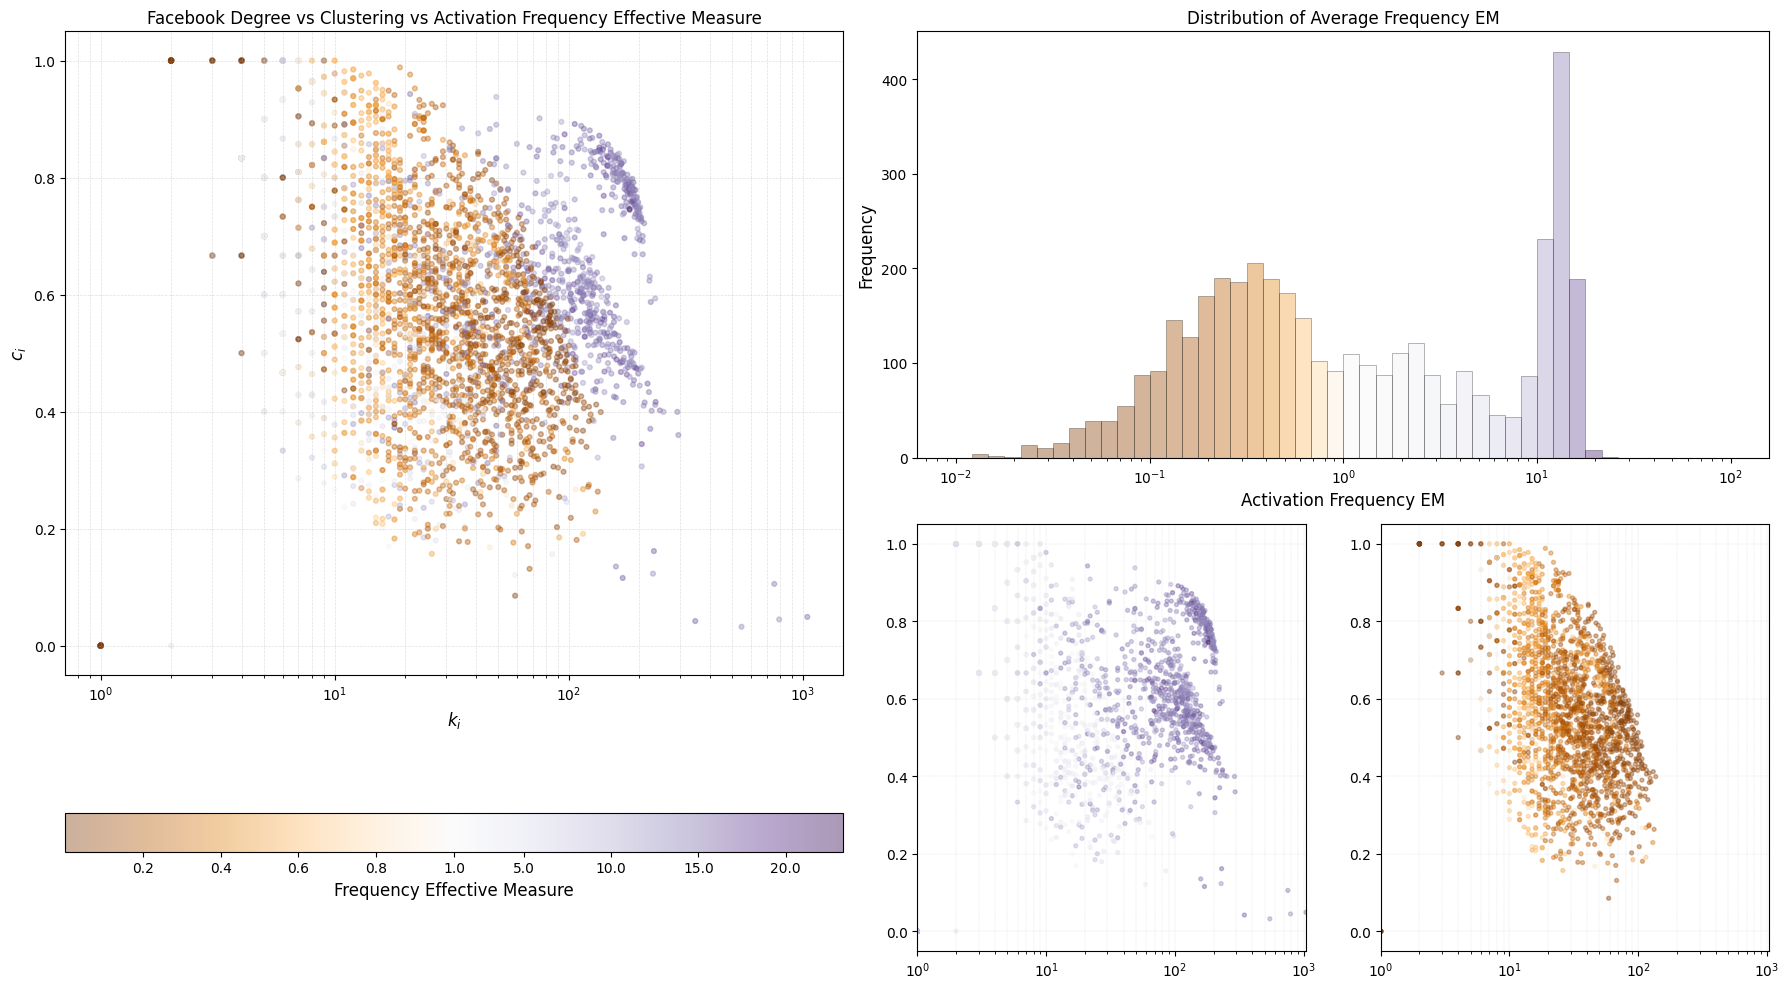

In [3]:
G = load_graph("datasets/fb.txt")

# Prepare clustering, degree and activation frequency
clustering = nx.clustering(G)
clustering_values = list(clustering.values())

degrees = dict(G.degree())

averages = load_pickle_file("em_results/fb/threshold_norm/fIA_0.050/mean_0.5_std_0.25/HD_effective_measures.pkl")
em_frequency = dict(zip(averages["nodeID"], averages["em_frequency"]))

# Prepare fig
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, width_ratios=[2, 1, 1], height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[:, 0])  # Left half: scatter plot
ax2 = fig.add_subplot(gs[0, 1:])  # Top right: histogram
ax3 = fig.add_subplot(gs[1, 1])  # Bottom right: axis 1
ax4 = fig.add_subplot(gs[1, 2])  # Bottom right: axis 2

# Prepare colot mapping
norm = TwoSlopeNorm(vmin=min(em_frequency.values()), vmax=max(em_frequency.values()), vcenter=1)
cmap = cm.PuOr

# Scatter plot
scatter = ax1.scatter(list(degrees.values()), clustering_values, c=list(em_frequency.values()), norm=norm, cmap=cmap, s=12, alpha=0.4)
ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.4)

# Add color bar
cbar = plt.colorbar(scatter, ax=ax1, orientation="horizontal")
cbar.set_label("Frequency Effective Measure", fontsize=12)

ticks = [4/5, 3/5, 2/5, 1/5, 1, 5, 10, 15, 20]
cbar.set_ticks(ticks)

# Labels and title
ax1.set_xlabel(r"$k_i$", fontsize=12)
ax1.set_xscale("log")
ax1.set_ylabel(r"$c_i$", fontsize=12)
ax1.set_title("Facebook Degree vs Clustering vs Activation Frequency Effective Measure")

num_bins = 25

# Create logarithmic bins below 1 and above 1
lower_bins = np.logspace(np.log10(0.01), np.log10(1), num_bins)
upper_bins = np.logspace(np.log10(1), np.log10(100), num_bins)

# Combine both ranges to create symmetric bins around 1
bins = np.concatenate([lower_bins, upper_bins])

n, bins, patches = ax2.hist(list(em_frequency.values()), edgecolor="black", linewidth=0.5, bins=bins, alpha=0.4)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
colors = cm.PuOr(norm(bin_centers))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax2.set_title("Distribution of Average Frequency EM")
ax2.set_xlabel("Activation Frequency EM", fontsize=12)
ax2.set_xscale("log")
ax2.set_ylabel("Frequency", fontsize=12)

pos_degrees, pos_clustering, pos_em_frequency = [], [], []
neg_degrees, neg_clustering, neg_em_frequency = [], [], []

for i in em_frequency.keys():
    if em_frequency[i] > 1:
        pos_degrees.append(degrees[str(i)])
        pos_clustering.append(clustering[str(i)])  
        pos_em_frequency.append(em_frequency[i])
    elif em_frequency[i] < 1:
        neg_degrees.append(degrees[str(i)])
        neg_clustering.append(clustering[str(i)])
        neg_em_frequency.append(em_frequency[i])

max_deg = max(degrees.values())

ax3.scatter(pos_degrees, pos_clustering, c=pos_em_frequency, norm=norm, cmap=cmap, s=8, alpha=0.4)
ax3.set_xlim(1, max_deg)
ax3.set_xscale("log")
ax3.grid(True, which="both", linestyle="--", linewidth=0.3, alpha=0.4)

ax4.scatter(neg_degrees, neg_clustering, c=neg_em_frequency, norm=norm, cmap=cmap, s=8, alpha=0.4)
ax4.set_xlim(1, max_deg)
ax4.set_xscale("log")
ax4.grid(True, which="both", linestyle="--", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()
